# Practical 10 — Perceptron Learning Algorithm

**Syllabus (Parul University):** *Implement Perceptron learning algorithm and evaluate performance.*  
**Kernel:** `ml-lab-kernel`  
**Data:** UCI Sonar (Mines `M` vs Rocks `R`), 208 samples, 60 energy bands.

### Outcomes

1. Heaviside neuron, Rosenblatt update, Novikoff bound.
2. NumPy `Perceptron` logging errors/epoch.
3. AND/OR converge; XOR does not (1969).
4. sklearn `Perceptron` + `StandardScaler` on Sonar.
5. Convergence curve, epoch-wise 2-D boundaries, AND vs XOR.
6. Confusion matrix, precision, recall.

---

## 1. Theory

### 1.1 Neuron model

Input $x\in\mathbb{R}^{d}$, weights $w\in\mathbb{R}^{d}$, bias $b\in\mathbb{R}$. Pre-activation

$$
z = w^{\top}x + b.
$$

**Heaviside / unit step** (Rosenblatt)

$$
\hat y = H(z)=\begin{cases}
1 & z\ge 0\\
0 & z< 0.
\end{cases}
$$

(The $\pm 1$ convention uses $\mathrm{sign}(z)$ with $\mathrm{sign}(0)=+1$. This lab uses $\{0,1\}$ so sklearn `Perceptron` lines up.)

The decision set $\{x:w^{\top}x+b=0\}$ is a **hyperplane**. One perceptron realises only **linearly separable** dichotomies.

### 1.2 Delta / Rosenblatt update

Learning rate $\eta>0$. For a labelled pair $(x,y)$, $y\in\{0,1\}$:

$$
w \leftarrow w + \eta\,(y-\hat y)\,x,
\qquad
b \leftarrow b + \eta\,(y-\hat y).
$$

If $\hat y=y$, the increment is **zero**. If $y=1,\hat y=0$, $w$ moves **toward** $x$; if $y=0,\hat y=1$, **away**. Equivalent $\pm 1$ form: on a mistake, $w\leftarrow w+\eta y x$.

### 1.3 Novikoff’s theorem (convergence)

Assume there exist $w_\star,b_\star$ and $\gamma>0$ such that $y'_i(w_\star^{\top}x_i+b_\star)\ge\gamma$ for all $i$ after mapping labels to $y'\in\{\pm 1\}$, and $\|x_i\|\le R$. Then the number of mistakes of the perceptron (with $\eta=1$, $w_0=0$) is at most

$$
M \le \left(\frac{R}{\gamma}\right)^{2}.
$$

If the data are **not** linearly separable (XOR), no such $\gamma>0$ exists and the algorithm **need not halt** at zero training error.

### 1.4 Minsky & Papert (1969)

A single linear threshold unit **cannot** represent XOR. Need a **multilayer** net (or extra features $x_1 x_2$).


## Colab 1-click header (skip upload on a campus PC)

**Google Colab**

1. Runtime → Run all (or run this cell, then **DATASET CONFIG**).
2. Own CSV: **upload** when prompted, or mount Drive and set `COLAB_DRIVE_CSV` in the config cell.
3. No file: the lab loader falls back to a public URL / sklearn.

**Local Jupyter (`ml-lab-kernel`)** — this cell only reports the runtime; packages should already be installed.


In [1]:
# --- Colab / local compatibility (safe to run everywhere) ---
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import HTML, display

IN_COLAB = "google.colab" in sys.modules


def _banner(text: str, bg: str = "#0f766e") -> None:
    display(
        HTML(
            f'<div style="background:{bg};color:#fff;padding:10px 14px;'
            f"border-radius:8px;font-family:Segoe UI,sans-serif;"
            f'font-weight:600;margin:6px 0;">{text}</div>'
        )
    )


def _rule(title: str = "") -> None:
    bar = "=" * 72
    if title:
        print(f"\n{bar}\n {title}\n{bar}")
    else:
        print(bar)


_banner("0 · Runtime")
print(f"Colab detected: {IN_COLAB}  |  Python {sys.version.split()[0]}")

if IN_COLAB:
    get_ipython().run_line_magic(
        "pip", "install -q numpy pandas matplotlib seaborn scikit-learn"
    )
    print("Colab: packages checked via %pip.")
else:
    print("Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.")


def colab_upload_to(dest: Path) -> Path | None:
    """1-click CSV upload on Colab."""
    if not IN_COLAB:
        return None
    from google.colab import files  # type: ignore

    uploaded = files.upload()
    if not uploaded:
        return None
    name, blob = next(iter(uploaded.items()))
    dest = dest if dest.suffix else dest / name
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(blob)
    print(f"Saved upload -> {dest}")
    return dest


def colab_mount_drive() -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")
    root = Path("/content/drive/MyDrive")
    return root if root.exists() else None


Colab detected: False  |  Python 3.14.0
Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.


## DATASET CONFIG BLOCK — edit this cell to swap your CSV

```text
  DATA_PATH  ──►  TARGET_COLUMN  ──►  DROP_COLUMNS (IDs, names, …)
       │                 │
       └── path relative to this notebook
```

> **Why this matters:** the model does not guess the label column. A wrong `TARGET_COLUMN` is a wrong experiment.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  DATASET CONFIG — edit this block to use your own CSV                ║
# ╚══════════════════════════════════════════════════════════════════════╝

DATA_PATH = 'data/sonar.csv'
TARGET_COLUMN = 'label'
DROP_COLUMNS = []

# Colab-only (ignored locally):
COLAB_DRIVE_CSV = None  # e.g. "/content/drive/MyDrive/my_data.csv"
COLAB_OFFER_UPLOAD = True

from pathlib import Path as _Path

print("=" * 72)
print(" DATASET CONFIG")
print("=" * 72)
print(f"DATA_PATH       = {DATA_PATH}")
print(f"TARGET_COLUMN   = {TARGET_COLUMN}")
print(f"DROP_COLUMNS    = {DROP_COLUMNS}")
_p = _Path(DATA_PATH)
print(f"local file exists: {_p.is_file()} ({_p.resolve() if _p.exists() else _p})")


 DATASET CONFIG
DATA_PATH       = data/sonar.csv
TARGET_COLUMN   = label
DROP_COLUMNS    = []
local file exists: True (D:\LiamCodes\parul-mtech-coding\ml-practical\10_Perceptron_Algorithm\data\sonar.csv)


In [3]:
_rule("cell output")
from __future__ import annotations

import sys
from pathlib import Path
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron as SkPerceptron
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (14, 7),   # why: large on-screen figures for lab projection / PDF
    "figure.dpi": 140,           # why: high-DPI rendering (sharp saved outputs)
    "savefig.dpi": 300,          # why: print-quality exports
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
pd.set_option("display.max_columns", 25)  # why: wide tables stay readable in the output pane
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", 40)
print("Python", sys.version.split()[0])


def _rule(title: str = "") -> None:
    bar = "=" * 72
    if title:
        print(f"\n{bar}\n {title}\n{bar}")
    else:
        print(bar)



 cell output


Python 3.14.0


## 2. NumPy `Perceptron` (errors per epoch)


In [4]:
class Perceptron:
    def __init__(self, eta: float = 1.0, n_epochs: int = 50, random_state: int = 42, shuffle: bool = True):
        self.eta = float(eta)
        self.n_epochs = int(n_epochs)
        self.random_state = random_state
        self.shuffle = shuffle
        self.w_: Optional[np.ndarray] = None
        self.b_: float = 0.0
        self.errors_per_epoch_: List[int] = []
        self.history_wb_: List[Tuple[np.ndarray, float]] = []

    def _heaviside(self, z: np.ndarray) -> np.ndarray:
        return (z >= 0).astype(np.int64)

    def net_input(self, X: np.ndarray) -> np.ndarray:
        return X @ self.w_ + self.b_

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self._heaviside(self.net_input(np.asarray(X, dtype=np.float64)))

    def fit(self, X: np.ndarray, y: np.ndarray) -> "Perceptron":
        rng = np.random.default_rng(self.random_state)
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.int64)
        n, d = X.shape
        self.w_ = np.zeros(d, dtype=np.float64)
        self.b_ = 0.0
        self.errors_per_epoch_ = []
        self.history_wb_ = [(self.w_.copy(), self.b_)]
        idx = np.arange(n)
        for _ in range(self.n_epochs):
            if self.shuffle:
                rng.shuffle(idx)
            mistakes = 0
            for i in idx:
                yhat = int(self.predict(X[i : i + 1])[0])
                delta = y[i] - yhat
                if delta != 0:
                    self.w_ += self.eta * delta * X[i]
                    self.b_ += self.eta * delta
                    mistakes += 1
            self.errors_per_epoch_.append(mistakes)
            self.history_wb_.append((self.w_.copy(), self.b_))
            if mistakes == 0:
                break
        return self


def gate_xy(kind: str) -> Tuple[np.ndarray, np.ndarray]:
    X = np.array([[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]])
    if kind == "AND":
        y = np.array([0, 0, 0, 1])
    elif kind == "OR":
        y = np.array([0, 1, 1, 1])
    elif kind == "XOR":
        y = np.array([0, 1, 1, 0])
    else:
        raise ValueError(kind)
    return X, y


## 3. Logic gates: AND / OR converge; XOR does not



 cell output
AND epochs 10 last errors 0 preds [0 0 0 1] true [0 0 0 1]
OR epochs 5 last errors 0 preds [0 1 1 1] true [0 1 1 1]
XOR epochs 40 last errors 3 preds [1 1 1 1] true [0 1 1 0]


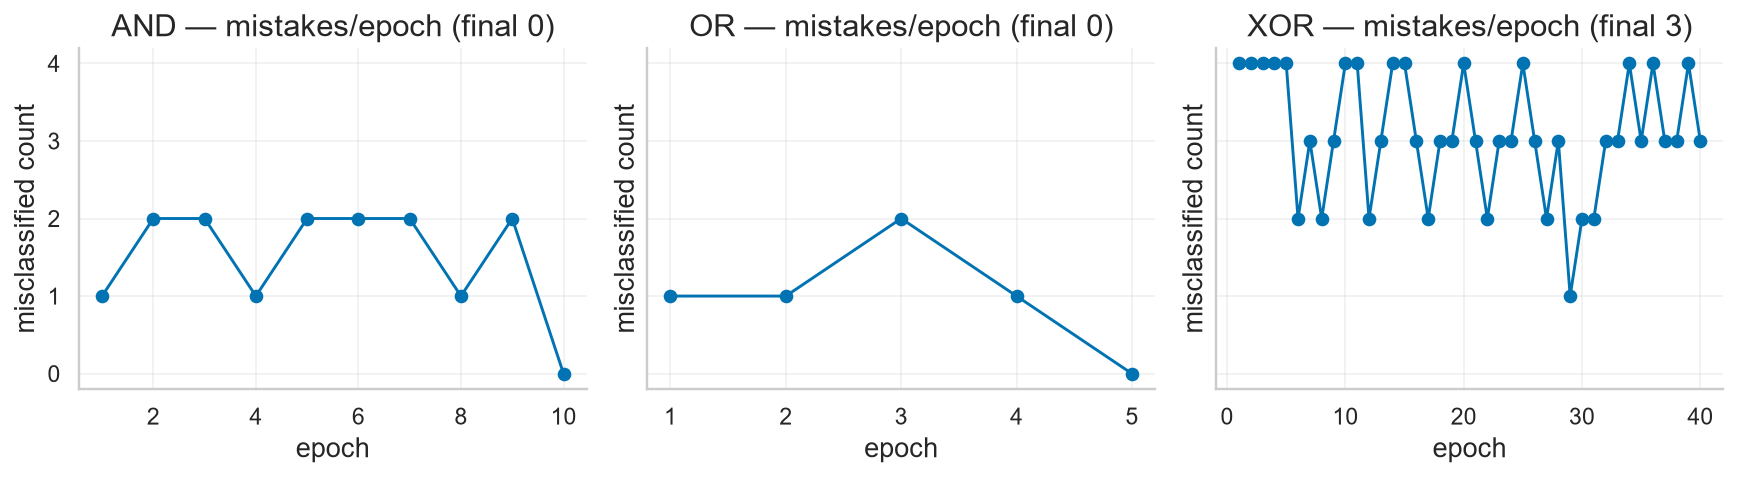

In [5]:
_rule("cell output")
fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.6), sharey=True)
gate_models = {}
for ax, g in zip(axes, ["AND", "OR", "XOR"]):
    Xg, yg = gate_xy(g)
    m = Perceptron(eta=1.0, n_epochs=40, random_state=SEED, shuffle=True).fit(Xg, yg)
    gate_models[g] = (m, Xg, yg)
    ax.plot(np.arange(1, len(m.errors_per_epoch_) + 1), m.errors_per_epoch_, marker="o")
    ax.set_title(f"{g} — mistakes/epoch (final {m.errors_per_epoch_[-1]})")
    ax.set_xlabel("epoch")
    ax.set_ylabel("misclassified count")
    print(g, "epochs", len(m.errors_per_epoch_), "last errors", m.errors_per_epoch_[-1], "preds", m.predict(Xg), "true", yg)
fig.tight_layout()
plt.show()


AND and OR are linearly separable $\Rightarrow$ Novikoff applies $\Rightarrow$ **zero training mistakes** after finitely many epochs. XOR is **not** separable: the error curve **does not settle at 0**.


## 4. 2-D decision boundary progression (AND) and AND vs XOR


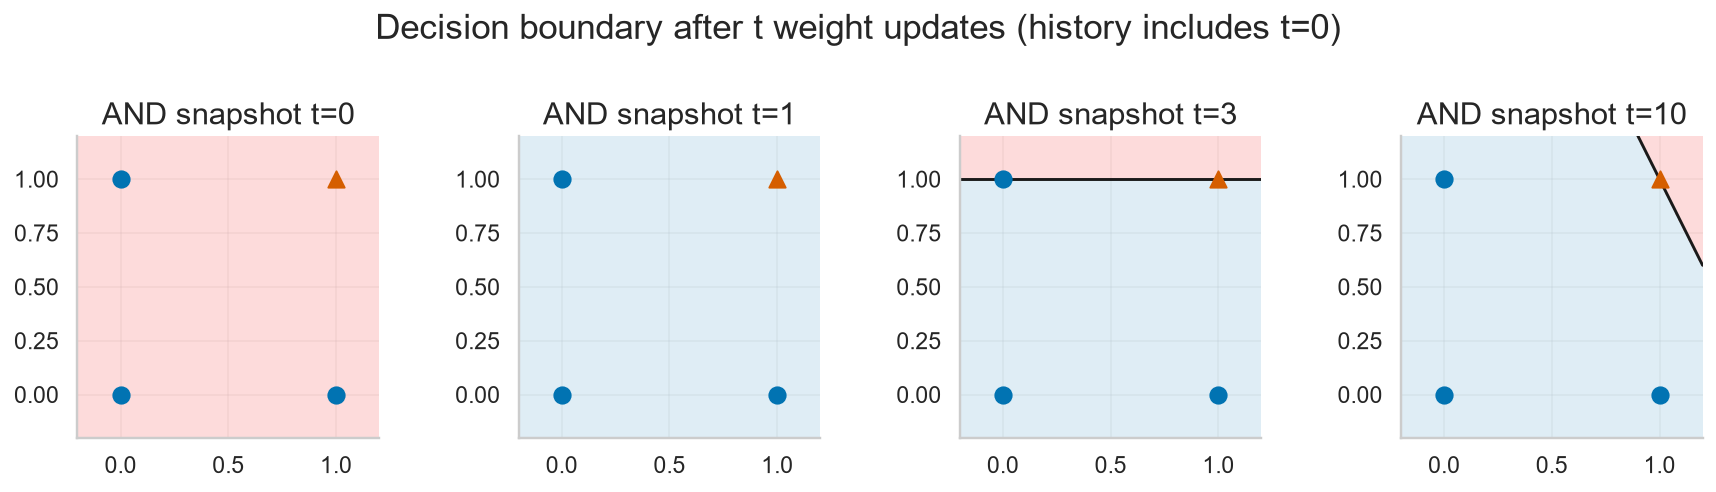

In [6]:
def plot_boundary(ax, w, b, X, y, title):
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="C0", s=70, label="0", zorder=3)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="C3", s=70, marker="^", label="1", zorder=3)
    xs = np.linspace(-0.2, 1.2, 200)
    if abs(w[1]) > 1e-12:
        ys = -(w[0] * xs + b) / w[1]
        ax.plot(xs, ys, "k-", lw=1.5)
    elif abs(w[0]) > 1e-12:
        ax.axvline(-b / w[0], color="k", lw=1.5)
    xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 120), np.linspace(-0.2, 1.2, 120))
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    zz = ((grid @ w + b) >= 0).astype(int).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=["#a6cee3", "#fb9a99"], alpha=0.35)
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.set_aspect("equal")
    ax.set_title(title)


# Snapshots from AND history
m_and, Xa, ya = gate_models["AND"]
snips = [0, min(1, len(m_and.history_wb_) - 1), min(3, len(m_and.history_wb_) - 1), len(m_and.history_wb_) - 1]
snips = sorted(set(snips))
fig, axes = plt.subplots(1, len(snips), figsize=(3.2 * len(snips), 3.2))
if len(snips) == 1:
    axes = [axes]
for ax, t in zip(axes, snips):
    w, b = m_and.history_wb_[t]
    plot_boundary(ax, w, b, Xa, ya, f"AND snapshot t={t}")
fig.suptitle("Decision boundary after t weight updates (history includes t=0)", y=1.05)
fig.tight_layout()
plt.show()


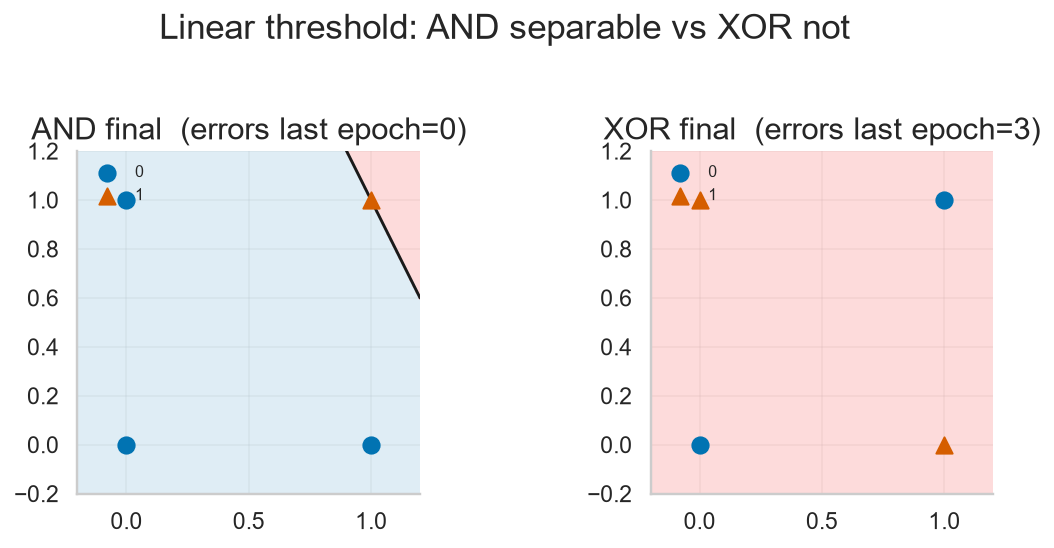

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.8))
for ax, g in zip(axes, ["AND", "XOR"]):
    m, Xg, yg = gate_models[g]
    plot_boundary(ax, m.w_, m.b_, Xg, yg, f"{g} final  (errors last epoch={m.errors_per_epoch_[-1]})")
    ax.legend(frameon=False, loc="upper left", fontsize=8)
fig.suptitle("Linear threshold: AND separable vs XOR not", y=1.03)
fig.tight_layout()
plt.show()


## 5. Dual-path Sonar load


In [8]:
_rule("cell output")
LOCAL = Path(DATA_PATH)
SONAR_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"


def load_sonar() -> Tuple[pd.DataFrame, str]:
    if LOCAL.is_file():
        return pd.read_csv(LOCAL), "local"
    try:
        raw = pd.read_csv(SONAR_URL, header=None)
        raw.columns = [f"f{i:02d}" for i in range(raw.shape[1] - 1)] + ["label"]
        return raw, "url"
    except Exception as exc:
        print("URL failed:", type(exc).__name__, exc)
        rng = np.random.default_rng(SEED)
        X = rng.normal(size=(40, 8))
        y = np.where(X[:, 0] + X[:, 1] > 0, "M", "R")
        cols = [f"f{i:02d}" for i in range(8)]
        mini = pd.DataFrame(X, columns=cols)
        mini["label"] = y
        return mini, "embedded_mini"


sonar, origin = load_sonar()
print("origin =", origin, "shape =", sonar.shape)
print(sonar["label"].value_counts())
sonar.iloc[:3, [0, 1, -1]]



 cell output
origin = local shape = (208, 61)
label
M    111
R     97
Name: count, dtype: int64


,f00,f01,label
0,0.0200,0.0371,R
1,0.0453,0.0523,R
2,0.0262,0.0582,R


## 6. sklearn `Perceptron` + `StandardScaler` on Sonar


In [9]:
_rule("cell output")
y = (sonar["label"].astype(str).str.upper() == "M").astype(int).to_numpy()  # mine = 1
X = sonar.drop(columns=["label"]).apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median(numeric_only=True)).to_numpy(dtype=np.float64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
print("train", X_train.shape, "test", X_test.shape, "mine rate", float(y_test.mean()))

pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("perc", SkPerceptron(max_iter=1000, eta0=1.0, random_state=SEED, shuffle=True)),
    ]
)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
print("test acc", round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, target_names=["rock R", "mine M"]))
print("precision(M)", round(precision_score(y_test, y_pred), 4), "recall(M)", round(recall_score(y_test, y_pred), 4))
print("n_iter sklearn", pipe.named_steps["perc"].n_iter_)



 cell output
train (156, 60) test (52, 60) mine rate 0.5384615384615384
test acc 0.8077
              precision    recall  f1-score   support

      rock R       0.79      0.79      0.79        24
      mine M       0.82      0.82      0.82        28

    accuracy                           0.81        52
   macro avg       0.81      0.81      0.81        52
weighted avg       0.81      0.81      0.81        52

precision(M) 0.8214 recall(M) 0.8214
n_iter sklearn 12


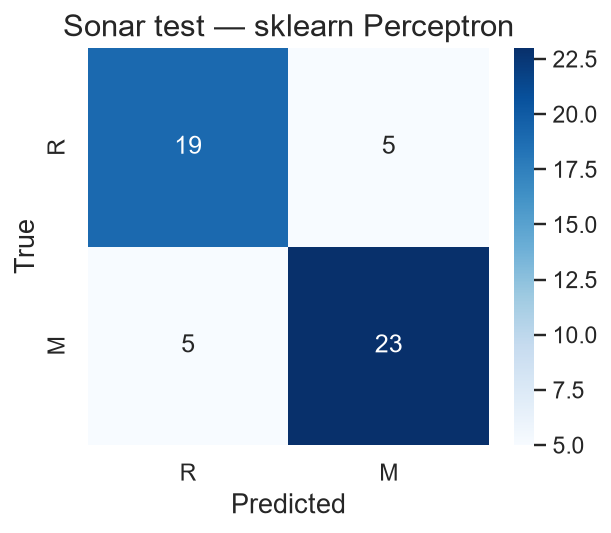

In [10]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4.0))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["R", "M"], yticklabels=["R", "M"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Sonar test — sklearn Perceptron")
fig.tight_layout()
plt.show()


## 7. Scratch Perceptron on scaled Sonar — error vs epoch



 cell output
scratch last-epoch mistakes (train) 10 n_epochs ran 80


scratch train acc 0.9294871794871795
scratch test acc 0.8076923076923077


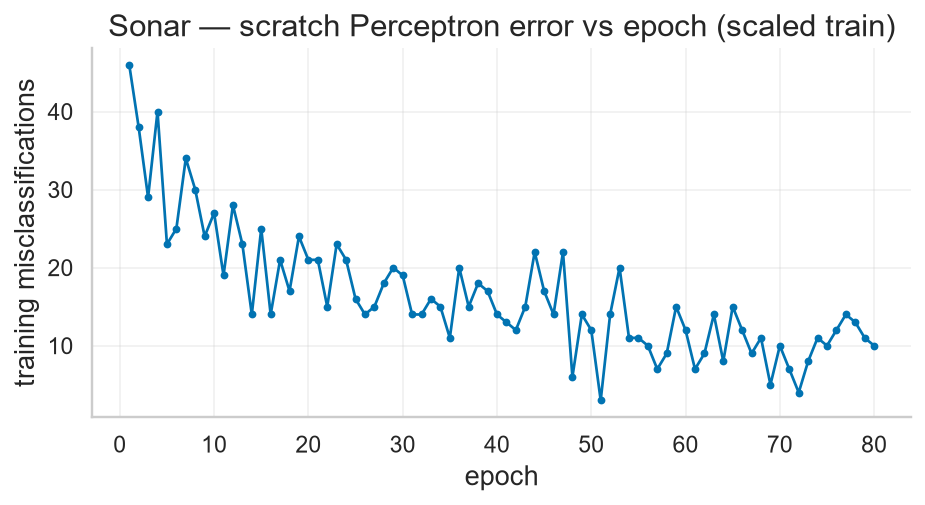

In [11]:
_rule("cell output")
scaler = StandardScaler().fit(X_train)
Xtr_s, Xte_s = scaler.transform(X_train), scaler.transform(X_test)
pp = Perceptron(eta=0.1, n_epochs=80, random_state=SEED, shuffle=True).fit(Xtr_s, y_train)
print("scratch last-epoch mistakes (train)", pp.errors_per_epoch_[-1], "n_epochs ran", len(pp.errors_per_epoch_))
print("scratch train acc", accuracy_score(y_train, pp.predict(Xtr_s)))
print("scratch test acc", accuracy_score(y_test, pp.predict(Xte_s)))

fig, ax = plt.subplots(figsize=(6.8, 3.8))
ax.plot(np.arange(1, len(pp.errors_per_epoch_) + 1), pp.errors_per_epoch_, marker=".", lw=1.4)
ax.set_xlabel("epoch")
ax.set_ylabel("training misclassifications")
ax.set_title("Sonar — scratch Perceptron error vs epoch (scaled train)")
fig.tight_layout()
plt.show()


Sonar in 60-D is **not guaranteed** separable; the curve may **plateau above zero**. That is expected — unlike AND.


## 8. 2-D PCA view of Sonar (illustration only)


C:\Users\OJAS\AppData\Local\Temp\ipykernel_38696\3368478194.py:9: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.tight_layout()
D:\LiamCodes\parul-mtech-coding\ml-practical\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


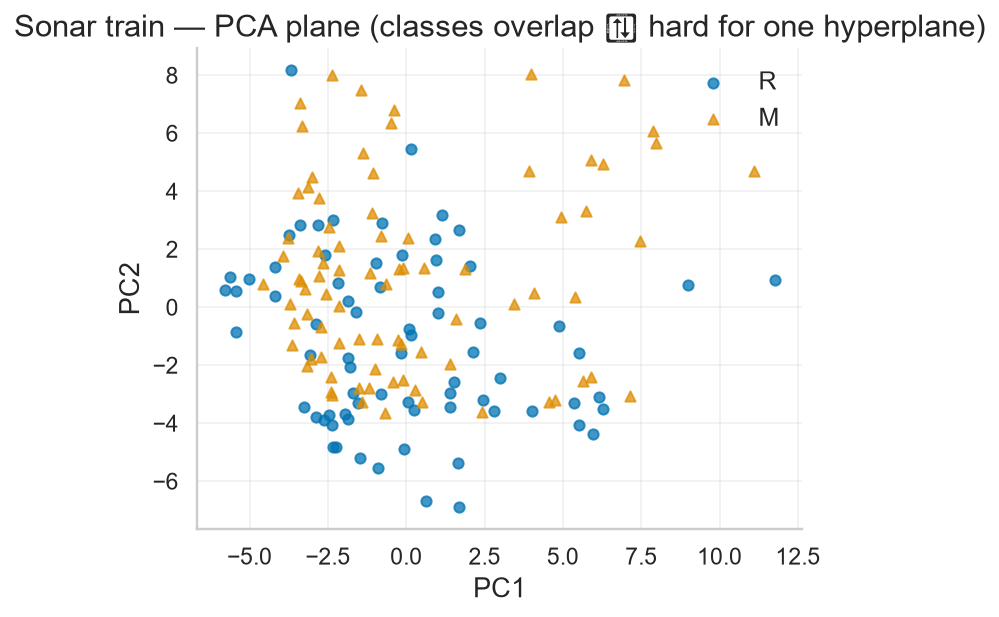

In [12]:
Z = PCA(n_components=2, random_state=SEED).fit_transform(Xtr_s)
fig, ax = plt.subplots(figsize=(5.4, 4.6))
ax.scatter(Z[y_train == 0, 0], Z[y_train == 0, 1], s=28, label="R", alpha=0.75)
ax.scatter(Z[y_train == 1, 0], Z[y_train == 1, 1], s=28, marker="^", label="M", alpha=0.75)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Sonar train — PCA plane (classes overlap ⇒ hard for one hyperplane)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 9. Viva-voce

**Q1. Write the Heaviside perceptron output.**  
**A.** $\hat y=H(w^{\top}x+b)$ with $H(z)=1$ iff $z\ge 0$.

**Q2. Weight update when a positive point is predicted 0?**  
**A.** $w\leftarrow w+\eta x$, $b\leftarrow b+\eta$.

**Q3. Novikoff bound meaning?**  
**A.** If a margin-$\gamma$ separator exists and $\|x\|\le R$, mistakes $\le (R/\gamma)^2$ — **finite** convergence.

**Q4. Why XOR fails?**  
**A.** The two classes are not linearly separable in $\mathbb{R}^{2}$. No $w,b$ give zero error.

**Q5. How to solve XOR?**  
**A.** Hidden layer / MLP, or explicit feature $x_1x_2$, or RBF/kernel model.

**Q6. Difference vs logistic regression?**  
**A.** Perceptron uses a **non-differentiable** step and only updates on errors. LogReg uses sigmoid + log-loss on all points (probabilistic).

**Q7. Why scale Sonar?**  
**A.** Bands have different energy scales; $\eta$ otherwise treats axes unevenly.

**Q8. sklearn `max_iter` vs our `n_epochs`?**  
**A.** Both cap passes over the data. sklearn may stop earlier via `tol` on loss.

**Q9. Is 100% train accuracy required on Sonar?**  
**A.** No. Overlapping mines/rocks in feature space violate Novikoff’s hypothesis.

**Q10. Precision vs recall for mines?**  
**A.** Precision: among predicted mines, true mines. Recall: among true mines, caught. Safety tasks often emphasise recall.

**Q11. Shuffle each epoch?**  
**A.** Classic Rosenblatt is sequential; shuffle reduces order artefacts.

**Q12. Bias term?**  
**A.** Equivalent to a constant feature $x_0=1$. Without $b$, the hyperplane is forced through the origin.


## 10. Summary

- Parul outcome: **implement the perceptron** and **evaluate** it — gates for **theory**, Sonar for **performance**.
- **AND/OR**: errors $\to 0$. **XOR**: errors persist (Minsky–Papert).
- Scratch NumPy logs **mistakes/epoch**; sklearn is the production API with **scaling**.
- Report **precision/recall**, not only accuracy, on mines vs rocks.

Do not edit `extra/`.

---
*End of Practical 10. Record load origin, AND/XOR last-epoch errors, sklearn test P/R. Kernel: `ml-lab-kernel`.*
